#Product Review Sentiment Rating Prediction
##Business Context
ShopSphere is one of the fastest-growing online marketplaces in North America, hosting over 200,000 third-party sellers and processing roughly 8 million product transactions per month. The platform spans consumer electronics, home goods, apparel, health and beauty, and a growing grocery vertical. Customer reviews are the lifeblood of the marketplace — they drive purchase decisions, influence search rankings, and serve as the primary feedback loop between buyers and sellers.

Over the past year, ShopSphere's Customer Experience team has noticed a troubling pattern: approximately 15% of customers who leave negative reviews (1-2 stars) had previously drafted partial reviews or engaged with the review prompt before ultimately submitting their feedback. The team hypothesizes that if they could predict a customer's likely rating before submission — using the draft review text combined with purchase metadata — they could proactively intervene with dissatisfied customers through targeted outreach, expedited resolutions, or service recovery offers.

The Director of Customer Experience, the VP of Marketplace Operations, and the Seller Success team are the primary stakeholders. The Director wants to reduce negative review volume by 20% through early intervention. The VP cares about overall marketplace health metrics and Net Promoter Score. The Seller Success team wants to identify systemic seller-level issues (e.g., a seller whose products consistently generate 1-2 star reviews despite positive delivery metrics, suggesting product quality problems).

Leadership has emphasized that this is fundamentally a customer retention initiative, not a review suppression tool. The model should identify genuinely dissatisfied customers who would benefit from proactive support — not attempt to influence or alter their feedback.

##The Problem
Predict the star rating (1-5) a customer will assign to a product based on their draft review text and purchase/product metadata. This is a multi-class classification problem with 5 ordered classes.

##Evaluation Criteria
The primary evaluation metric is weighted F1 score, which accounts for the class imbalance in ratings. However, the business particularly cares about:

* Recall for 1-star and 2-star ratings: Missing a dissatisfied customer (predicting 4-5 stars when the true rating is 1-2) means a lost intervention opportunity. These customers are most likely to churn.
* Avoiding extreme misclassification: Predicting 5 stars when the true rating is 1 star (or vice versa) is far worse than predicting 3 stars when the true rating is 2. The ordinal nature of ratings matters.
* Precision for intervention triggers: If the model triggers intervention for too many customers who are actually satisfied, the outreach team will be overwhelmed and the program loses credibility.

A secondary metric worth examining is macro-averaged mean absolute error across rating classes, which penalizes predictions that are far from the true rating more heavily.

##Data Description
| Feature|	Type	| Description |
|--------|------|-------------|
|review_text|	text|	Customer's draft product review (40-120 words)|
|product_price|	float|	Product price in dollars|
|product_category|	int (0-7)|	Encoded product category|
|seller_rating|	float (1-5)|	Seller's overall marketplace rating|
|delivery_days|	int|	Days from order to delivery|
|product_age_months|	int|	Months since product was first listed|
|num_previous_reviews_by_user|	int|	Number of prior reviews by this customer|
|verified_purchase|	binary|	Whether the purchase is verified (0/1)|
|return_initiated|	binary|	Whether a return was initiated (0/1)|
|helpful_votes|	int	|Helpful votes on the review draft (from preview)|
|discount_pct|	float|	Discount percentage applied at purchase|
|product_weight_kg|	float	|Product shipping weight in kilograms|
|image_count|	int	|Number of images attached to the review|
|rating|	int (1-5)|	Target: star rating|

##Text Field Details
The `review_text` column contains customer-written product reviews ranging from approximately 40 to 120 words. Reviews for higher ratings tend to use positive vocabulary (e.g., "amazing," "excellent," "recommend," "perfect"), while lower ratings use negative vocabulary (e.g., "terrible," "waste," "defective," "refund"). Three-star reviews often contain hedging language ("okay," "decent," "average," "mixed").

Importantly, approximately 10% of reviews are "deceptive" in that the text sentiment does not match the rating. For example, a customer may write positively about the product itself but assign a low rating due to delivery problems or seller issues captured in the structured features. Conversely, some forgiving customers write lukewarm text but still assign high ratings. This means text alone is not sufficient for accurate prediction — structured features provide complementary signal.

##Special Considerations
Ordinal target: While treated as multi-class, the ratings have a natural order. A model that predicts 3 when the true value is 2 is less wrong than one that predicts 5. Consider whether ordinal approaches or standard multi-class classification work better.
Text-structure interaction: Some low ratings stem from product quality issues (captured in text), while others stem from delivery or seller issues (captured in structured features like delivery_days, return_initiated, seller_rating). The best models should learn to combine both signals.
Class imbalance: 1-star reviews are only 10% of the data. Consider stratified approaches or class weighting.
Deceptive reviews: The ~10% of reviews where text and rating disagree create a ceiling on text-only model performance and reward models that integrate structured features.
Evaluation drift: The test period reflects a time with slightly slower delivery, lower seller ratings, and higher discount activity — simulating a post-holiday marketplace shift.

##Cost/Impact Table
|True Rating	|Predicted Rating|	Impact|
|-------------|----------------|--------|
|1-2 (dissatisfied)	|1-2|	Correct: customer flagged for proactive outreach, potential save|
|1-2 (dissatisfied)	|4-5|	Missed opportunity: dissatisfied customer receives no intervention, likely churns|
|4-5 (satisfied)	|1-2	|False alarm: outreach team contacts a happy customer unnecessarily, wastes resources|
|4-5 (satisfied)	|4-5	|Correct: no action needed|
|3 (neutral)	|1-2	|Minor false alarm: customer may appreciate proactive check-in regardless|
|3 (neutral)	|4-5	|Acceptable: neutral customers are lower priority for intervention|
|1|	5 (or vice versa)	|Extreme misclassification: suggests fundamental model failure, damages trust in system|

# Part 1: Business Understanding & Text Strategy
##1.1 Problem Restatement

- The business problem is to predict the star rating (1-5) a customer will assign to a product based on their draft review text and product metadata. Enabling proactive intervention with dissatisfied customers before they submit a negative review.
- The primary stakeholders are the Director of Customer Experience, the VP of Marketplace Operations, and the Seller Success team.
- The model would inform decisions about early intervention strategies. It will identify dissatisfied customers, such as targeted outreach, expedited resolutions, or service recovery offers.
- This is a multi-class classification problem. The implication of this is the ordinal nature of the ratings matters. The standard multi-class classification metrics need to be carefully selected. For example, weighted F1 score, recall for 1 star and 2 star ratings.

##1.2 Metric Selection


For multi-class scenarios: Weighted F1 vs Macro F1 vs per-class precision/recall — which fits the business problem? Are all classes equally important, or is misclassifying the critical class (e.g., Immediate triage) catastrophically worse than misclassifying between non-critical classes?
For regression scenarios: RMSE vs MAE vs R² — which captures the business loss function? Is predicting $50K salary instead of $100K (50% off in log-scale) worse than predicting $200K instead of $250K (20% off in log-scale)? If so, consider MAPE or log-RMSE.

- The primary evaluation metric that best captures the cost of being wrong is the weighted F1 score because it accounts for class imbalance. However, not all classes are equally important.
- Misclassifying certain classes is significantly worse. For example, predicting 5 stars for a 1 star review is extreme missclassification that damages trust in the system. To capture the ordinal nature and penalize predictions that are far from the true rating more, macro-averaged Mean Absolute Error (MAE) across rating classes would be a potential secondary metric.

##1.3 Text Strategy

Preprocessing: lowercasing, punctuation handling, stop words, stemming/lemmatization

- The review_text will be processed using TF-IDF vectorization, as it captures the importance of words relative to the entire corpus rather than just raw frequency. This helps reduce the impact of very common but uninformative words.

- The TF-IDF vectorizer will be configured with parameters such as max_features, ngram_range, and min_df to balance vocabulary richness and overfitting risk. These parameters will be tuned to optimize model performance.

- Because TF-IDF produces a high-dimensional sparse matrix, TruncatedSVD will be applied to reduce dimensionality. This improves computational efficiency and helps mitigate overfitting while retaining the most important semantic structure of the text.

##1.4 Feature Integration Strategy


- A concatenation strategy using ColumnTransformer and Pipeline will be used to integrate text and structured features. This ensures that all preprocessing steps are applied consistently and are fit only on training data during cross-validation, preventing data leakage.

- Structured numerical features will be scaled using StandardScaler, as many machine learning models are sensitive to feature magnitude. Categorical features will be encoded using one-hot encoding to convert them into a machine-readable format.
The review_text will be transformed using TF-IDF followed by TruncatedSVD, and then combined with structured features into a single feature matrix.

- This approach is chosen because it allows the model to learn from both textual sentiment and structured attributes simultaneously, while maintaining a reproducible and leakage-safe pipeline, consistent with best practices in machine learning workflows.


# Part 2: Data Exploration & Preparation

## 2.1 Structured Data EDA
* Standard exploration of numeric/categorical features, distributions, correlations, missing values.

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   review_text                   2000 non-null   object 
 1   product_price                 2000 non-null   float64
 2   product_category              2000 non-null   int64  
 3   seller_rating                 2000 non-null   float64
 4   delivery_days                 2000 non-null   int64  
 5   product_age_months            2000 non-null   int64  
 6   num_previous_reviews_by_user  2000 non-null   int64  
 7   verified_purchase             2000 non-null   int64  
 8   return_initiated              2000 non-null   int64  
 9   helpful_votes                 2000 non-null   int64  
 10  discount_pct                  2000 non-null   float64
 11  product_weight_kg             2000 non-null   float64
 12  image_count                   2000 non-nu

None


--- Missing Values ---


,0
review_text,0
product_price,0
product_category,0
seller_rating,0
delivery_days,0
product_age_months,0
num_previous_reviews_by_user,0
verified_purchase,0
return_initiated,0
helpful_votes,0



--- Numerical Summary ---


,product_price,product_category,seller_rating,delivery_days,product_age_months,num_previous_reviews_by_user,verified_purchase,return_initiated,helpful_votes,discount_pct,product_weight_kg,image_count,rating
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,47.05,3.44,4.02,4.05,29.48,3.02,0.69,0.14,2.00,25.06,1.35,3.42,3.34
std,43.31,2.30,0.62,3.24,16.90,1.73,0.46,0.35,1.41,14.44,1.20,2.30,1.25
min,5.00,0.00,1.69,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.10,0.00,1.00
25%,20.08,1.00,3.59,2.00,15.00,2.00,0.00,0.00,1.00,12.50,0.57,1.00,2.00
50%,34.67,3.00,4.05,3.00,29.00,3.00,1.00,0.00,2.00,25.35,0.98,3.00,4.00
75%,58.20,5.00,4.48,5.00,44.00,4.00,1.00,0.00,3.00,37.50,1.69,5.00,4.00
max,500.00,7.00,5.00,25.00,59.00,10.00,1.00,1.00,8.00,50.00,10.03,7.00,5.00



--- Categorical Summary ---


,review_text
count,2000
unique,2000
top,The product is adequate and matched its purpos...
freq,1



--- Class Imbalance (Rating Distribution) ---


,Count,Percentage (%)
rating,,
1,217,10.85
2,292,14.60
3,475,23.75
4,618,30.90
5,398,19.90


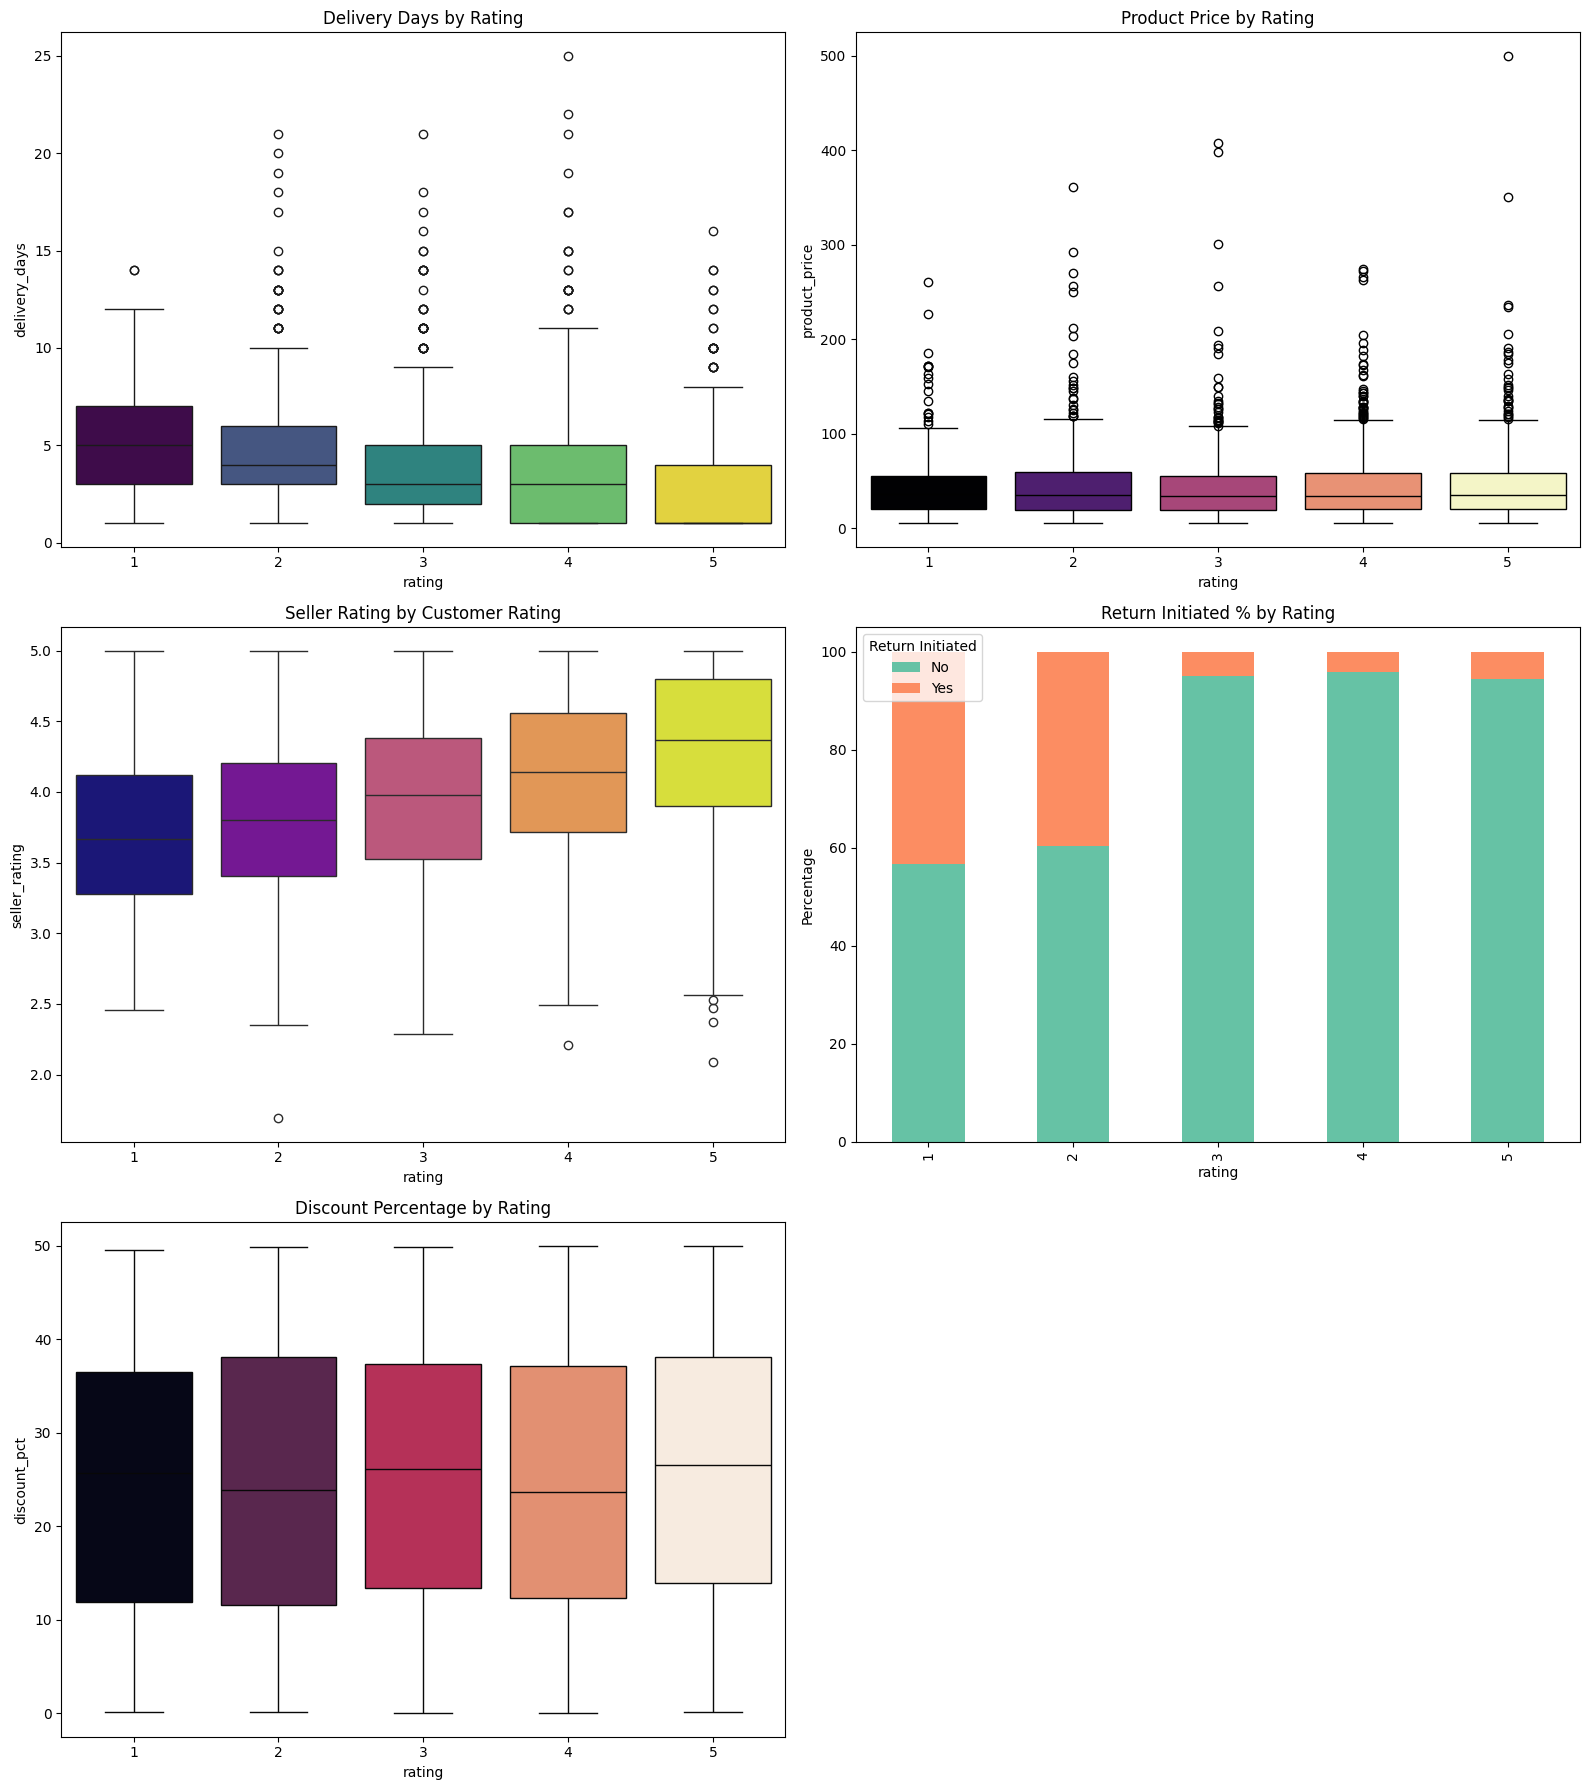

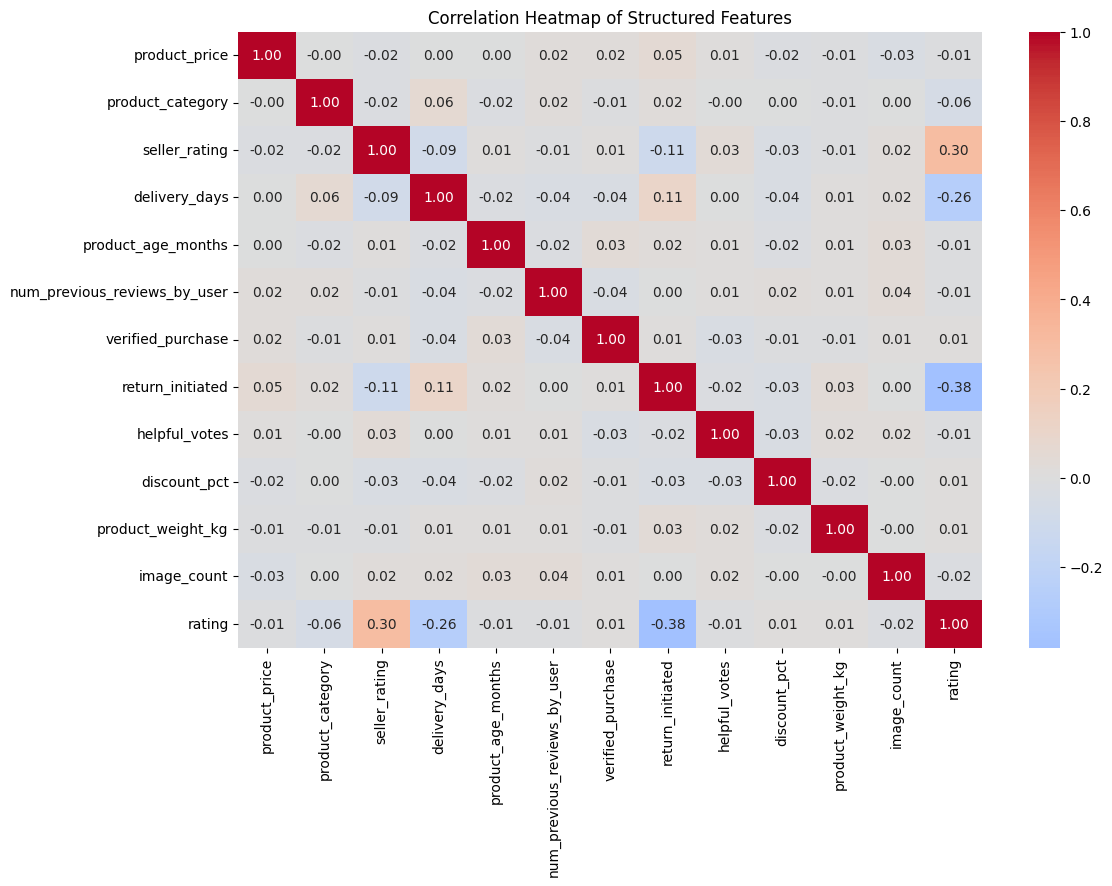

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set pandas display option to show no more than 2 decimal places
pd.options.display.float_format = '{:.2f}'.format

# Define the URL for the training dataset
data_url = 'https://raw.githubusercontent.com/prof-tcsmith/ism6251s26-data/main/FinalProject/cases/21-product-review-sentiment/train.csv'

# Load the dataset into a pandas DataFrame
df = pd.read_csv(data_url)

# 1. Basic Information
print("--- Dataset Info ---")
display(df.info())

# 2. Check for Missing Values
print("\n--- Missing Values ---")
display(df.isnull().sum())

# 3. Descriptive Statistics for Numerical Features
print("\n--- Numerical Summary ---")
display(df.describe().round(2))

# 4. Descriptive Statistics for Categorical Features
print("\n--- Categorical Summary ---")
display(df.describe(include=['object', 'bool']))

# 5. Class Imbalance Analysis
print("\n--- Class Imbalance (Rating Distribution) ---")
rating_counts = df['rating'].value_counts().sort_index()
rating_pct = df['rating'].value_counts(normalize=True).sort_index() * 100
imbalance_df = pd.DataFrame({'Count': rating_counts, 'Percentage (%)': rating_pct})
display(imbalance_df)

# 6. Feature Impact Analysis - Visualizations
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Plot 1: Delivery Days vs Rating
sns.boxplot(ax=axes[0, 0], data=df, x='rating', y='delivery_days', hue='rating', palette='viridis', legend=False)
axes[0, 0].set_title('Delivery Days by Rating')

# Plot 2: Product Price vs Rating
sns.boxplot(ax=axes[0, 1], data=df, x='rating', y='product_price', hue='rating', palette='magma', legend=False)
axes[0, 1].set_title('Product Price by Rating')

# Plot 3: Seller Rating vs Rating
sns.boxplot(ax=axes[1, 0], data=df, x='rating', y='seller_rating', hue='rating', palette='plasma', legend=False)
axes[1, 0].set_title('Seller Rating by Customer Rating')

# Plot 4: Return Initiated vs Rating
return_rating = pd.crosstab(df['rating'], df['return_initiated'], normalize='index') * 100
return_rating.plot(kind='bar', stacked=True, ax=axes[1, 1], color=['#66c2a5', '#fc8d62'])
axes[1, 1].set_title('Return Initiated % by Rating')
axes[1, 1].set_ylabel('Percentage')
axes[1, 1].legend(title='Return Initiated', labels=['No', 'Yes'])

# Plot 5: Discount Percent vs Rating
sns.boxplot(ax=axes[2, 0], data=df, x='rating', y='discount_pct', hue='rating', palette='rocket', legend=False)
axes[2, 0].set_title('Discount Percentage by Rating')

# Remove the empty 6th subplot
fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.show()

# 7. Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr().round(2)
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Structured Features')
plt.show()

EDA was performed on the training dataset only to avoid data leakage. It still shows the patterns of the data, but avoid any knowledge of the test data to prevent any influence on the model.

This dataset contains 2000 rows and 14 features, with text as a feature. There are no missing values across all features.

Based on the rating distribution, it is clear that the dataset is imbalanced, and even though the majority is in the higher ranks, still 10.85% has rating of 1 and 14.60% has rating of 2, which will allow us to learn more about these types of customers to help the company achieve the goal.

The numerical summary shows all statistical information regarding each feature. Additionally, some features have graphs that show the relationship between a feature and rating. The correlation heatmap also helps show which features correlate with the rating.

For instnace, product_price shows that the price can be a minimum of 5 and a maximum is 500, which is a big range, and it may lead to the point that there are various products and they are not in the same categories. However, based on the graph, price does not affect the rating very much, since some high-priced items have different ratings.

Another example is delivery_days, which shows that delivery minimum is 1 day and the maximum is 25, but the average is about 4 days, and the majority of delivery days are between 1 and 5 days. In the graph, we can see that longer delivery days are mostly in ratings 2, 3, and some 4, which may indicate that this feature somewhat affects the rating. In the heatmap, the correlation is -0.26 between delivery days and rating which means that it is a weak negative relationship between them (as delivery days increas, rating is decreasing). Relationship is not strong, more on the weaker side.

seller_ratings shows a correlation between seller rating and rating overall (0.3 in the correlation heatmap), which means that a lower seller rating most likely will have more negative reviews. The means of the rating is about 4, which is good, since it means that the majority is high or good ratings.

return_initiated shows that lower rating has way more returns than high rating products, and it means that it is a signal of dissatisfaction of customers. Mean of this feature shows that 14% is only returns.

discount_pct has a wide range from 0% till 50% with 25.06% as the mean. The graph does not really show the difference between discount and rating, so we can say that this feature does not have a strong correlation with satisfaction or dissatisfaction.


##2.2 Text Data EDA

* Vocabulary size before and after preprocessing
* Document length distribution (word count histogram)
* Most common terms overall
* Most common terms by target class/level — does the vocabulary differentiate classes visibly? This preview tells you how much signal TF-IDF will extract.
* Sample documents from different target categories

--- Training Data Vocabulary Analysis ---
Vocabulary size (raw): 411
Vocabulary size (after basic cleaning): 324

--- Top 15 Most Common Terms Overall ---


,Frequency
this,6977
product,1821
quality,1438
after,1290
about,1097
compared,882
purchase,863
overall,822
expectations,792
accessory,757


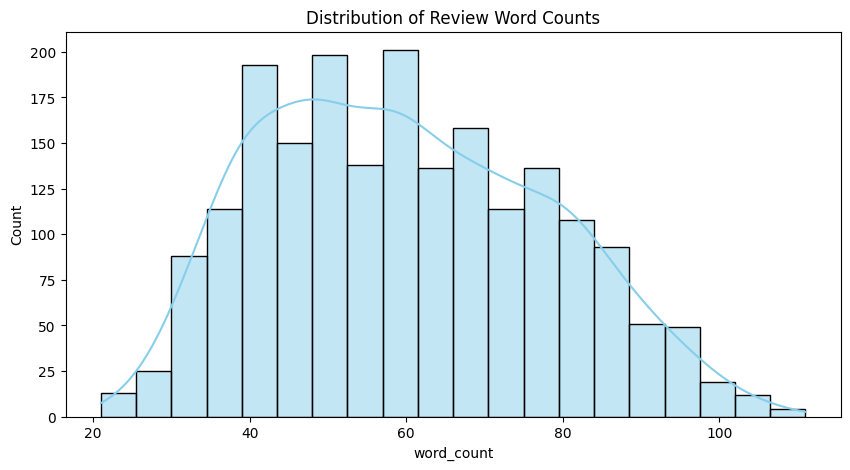


--- Word Count Distribution by Rating ---


,Review Count,Percentage (%)
rating,,
1,217,10.85
2,292,14.60
3,475,23.75
4,618,30.90
5,398,19.90



--- Top Words by Rating ---
Rating 1: this, product, arrived, after, quality, experience, found, buying, overall, equipment
Rating 2: this, product, after, overall, quality, compared, purchase, experience, find, tool
Rating 3: this, product, about, after, overall, quality, what, basic, have, price
Rating 4: this, product, quality, after, about, expectations, using, compared, bought, would
Rating 5: this, quality, product, after, bought, expectations, about, family, compared, purchase

--- Sample Reviews per Rating Category ---

[Rating 1] Sample:
The tool arrived damaged and the overall experience was terrible. I found this product to be unusable and the quality is defective. Compared to the description this device is defective and misleading. After just a few days this device proved to be disappointing. I expected much better but this appliance is horrible at best. The price seemed fair for what you get.

[Rating 2] Sample:
The tool arrived damaged and the overall experience was drea

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset to ensure 'df' is defined
data_url = 'https://raw.githubusercontent.com/prof-tcsmith/ism6251s26-data/main/FinalProject/cases/21-product-review-sentiment/train.csv'
df = pd.read_csv(data_url)

# 1. Vocabulary Size Analysis (Training Data)
raw_text = ' '.join(df['review_text'])
raw_vocab = set(raw_text.split())
clean_text = raw_text.lower()
for char in '.,!?:;"()':
    clean_text = clean_text.replace(char, '')
processed_vocab = set(clean_text.split())

print(f'--- Training Data Vocabulary Analysis ---')
print(f'Vocabulary size (raw): {len(raw_vocab)}')
print(f'Vocabulary size (after basic cleaning): {len(processed_vocab)}')

# 2. Most Common Terms Overall
print('\n--- Top 15 Most Common Terms Overall ---')
# Clean and split the entire corpus to find common words (len > 3 to avoid noise)
all_words = clean_text.split()
long_words = [w for w in all_words if len(w) > 3]
top_overall = pd.Series(long_words).value_counts().head(15)
display(top_overall.to_frame(name='Frequency'))

# 3. Word Count Distribution
df['word_count'] = df['review_text'].str.split().str.len()
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Review Word Counts')
plt.show()

# 4. Word Count Distribution by Rating
print('\n--- Word Count Distribution by Rating ---')
counts = df['rating'].value_counts().sort_index()
pct = (df['rating'].value_counts(normalize=True).sort_index() * 100).round(2)
display(pd.DataFrame({'Review Count': counts, 'Percentage (%)': pct}))

# 5. Top Words by Rating Class
print('\n--- Top Words by Rating ---')
for r in sorted(df['rating'].unique()):
    cat_text = ' '.join(df[df['rating'] == r]['review_text']).lower()
    for char in '.,!?:;"()':
        cat_text = cat_text.replace(char, '')
    cat_words = [w for w in cat_text.split() if len(w) > 3]
    top_cat = pd.Series(cat_words).value_counts().head(10).index.tolist()
    print(f'Rating {r}: {", ".join(top_cat)}')

# 6. Sample documents
print('\n--- Sample Reviews per Rating Category ---')
for r in sorted(df['rating'].unique()):
    sample = df[df['rating'] == r]['review_text'].iloc[0]
    print(f'\n[Rating {r}] Sample:\n{sample}')

After preprocessing (removing commas, lowecasing, etc. ), the vocabulary shows that it is 324 words, when the raw vocabulary was 411 words.

Most frequent terms make sense since they are words that are common in the reviews, and based on the output, we can see that they appear in many ratings. For instance, "after", "product", "quality", etc. TF-IDF will reduce the weight of these words.

Based on the graph and the table, we can see that the majority of reviews have a rating of 3 or 4, and low rating like 1 has 10.85%, which means that the data is imbalanced and needs to have recall, precision, and F-beta during the model evaluation. Also, 10.85% will allow us to see the patterns of dissatisfied customers and help to prevent it.

Top words by rating are now not very clear since top words are too common and identifcal. For example, "this", "quality", "product", "expectations" are repeating in many ratings, which indicate that there are a limited separation of words between ratings and it will be a challenge for TF-IDF.  


## 2.3 Reproducible Pipeline Build a preprocessing pipeline that:

* Fits TF-IDF vectorizer on training data only (critical for no leakage)
* Applies TruncatedSVD only after TF-IDF
* Scales structured features with StandardScaler inside a Pipeline (refit per CV fold)
* Produces a combined feature matrix


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import pandas as pd

# Identify feature types for the pipeline
text_feature = 'review_text'
structured_features = [
    'product_price', 'product_category', 'seller_rating', 'delivery_days',
    'product_age_months', 'num_previous_reviews_by_user', 'verified_purchase',
    'return_initiated', 'helpful_votes', 'discount_pct', 'product_weight_kg', 'image_count'
]

# 1. Define the Text Pipeline with updated TF-IDF parameters
text_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2), min_df=5, max_df=0.9)),
    ('svd', TruncatedSVD(n_components=100, random_state=42))
])

# 2. Define the Structured Pipeline
structured_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# 3. Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_pipeline, text_feature),
        ('struct', structured_pipeline, structured_features)
    ]
)

# Fit and transform the data
processed_features = preprocessor.fit_transform(df)

# Create a DataFrame for the combined matrix
text_names = [f'svd_comp_{i}' for i in range(100)]
struct_names = structured_features
combined_df = pd.DataFrame(processed_features, columns=text_names + struct_names)

print(f"Original shape: {df[structured_features + [text_feature]].shape}")
print(f"Processed feature matrix shape: {combined_df.shape}")
print("\n--- Combined Feature Matrix Preview ---")
display(combined_df.head())
print("\nPipeline successfully built and applied with updated TF-IDF parameters.")

Original shape: (2000, 13)
Processed feature matrix shape: (2000, 112)

--- Combined Feature Matrix Preview ---


,svd_comp_0,svd_comp_1,svd_comp_2,svd_comp_3,svd_comp_4,svd_comp_5,svd_comp_6,svd_comp_7,svd_comp_8,svd_comp_9,...,seller_rating,delivery_days,product_age_months,num_previous_reviews_by_user,verified_purchase,return_initiated,helpful_votes,discount_pct,product_weight_kg,image_count
0,0.40,-0.32,-0.10,-0.11,0.06,-0.03,0.02,0.26,0.07,0.18,...,-0.15,-0.94,1.69,-0.59,0.66,-0.40,0.71,-0.86,-0.82,0.25
1,0.33,-0.21,-0.23,0.29,0.02,-0.00,-0.06,-0.06,-0.04,-0.13,...,0.83,-0.94,-0.21,1.14,0.66,-0.40,0.00,1.66,-0.68,0.25
2,0.17,-0.03,0.04,-0.01,-0.01,0.02,-0.05,-0.03,-0.03,-0.11,...,-0.07,-0.32,0.86,-0.59,0.66,-0.40,-0.71,-1.53,-0.22,0.69
3,0.30,-0.22,-0.07,0.11,-0.08,-0.02,0.02,-0.17,-0.03,-0.01,...,0.26,-0.32,0.74,-1.75,0.66,-0.40,-0.71,-0.21,0.24,0.25
4,0.30,-0.06,-0.07,0.16,0.07,0.01,-0.14,-0.07,-0.17,-0.14,...,-0.52,-0.94,-0.74,-0.59,-1.51,-0.40,1.42,0.62,4.10,-0.18



Pipeline successfully built and applied with updated TF-IDF parameters.


TF_IDF:
* max_features=5000, since based on EDA, the vocabulary is on the smaller side, it is only 324 words, which means that 5000 will help to ensure that all useful words and bigrams as well are captured (bigrams will incerease the vocabulary).

* ngram_range=(1,2) will help to add bigrams to understand the context and improve classification, since words like "not good" may often be in reviews.

* min_df=5 ensures that all very rare words are removed since they are noise, and since there are 2000 rows in this dataset, words that are there less than 5 times are not very significant, and it will be hard to generalize them.

* max_df=0.9, which means that it will remove very common words,since they are not informative and will not help in this case.

* stop_words='english' removes words that are noise and do not mean anything, like "and", "this", etc.

Truncated SVD:

* n_components=100, because the dataset is 2000 rows, and this number will help to avoid overfitting and reduce some noise. It will be helpful since TF-IDF makes it sparse and high-dimensional. If the number of components is lower, it may lose important information, but if it is a large number, then it will have too much noise.

StandardScaler will help to balance between features, since some of the has a big range and some do not, so it will standardize it.

Column Transofrmer needs to be used since the dataset contains text and structured features, so it will allow combining into a single feature matrix. It will also help during the training to avoid leakage.


#Part 3: Model Development
##3.1 Required Ablation Study

We compare three configurations for every model type we try:

| Configuration | What it uses |
|---------------|--------------|
| Structured-only | Scaled structured features, no text |
| Text-only | TF-IDF → (optional SVD), no structured features |
| Combined | Both, concatenated |

The ablation demonstrates whether combining modalities was the right call. Sometimes text alone dominates and structured is noise (low signal on structured features); sometimes structured dominates (short or uninformative text); sometimes combining is clearly better.

In [ ]:
# Part 3.1 Required Ablation Study
# Structured-only vs Text-only vs Combined

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import f1_score, make_scorer


# Target and feature setup

target = "rating"
text_feature = "review_text"

numeric_features = [
    "product_price",
    "seller_rating",
    "delivery_days",
    "product_age_months",
    "num_previous_reviews_by_user",
    "verified_purchase",
    "return_initiated",
    "helpful_votes",
    "discount_pct",
    "product_weight_kg",
    "image_count"
]

categorical_features = [
    "product_category"
]

structured_features = numeric_features + categorical_features

X = df[[text_feature] + structured_features].copy()
y = df[target].copy()

X[text_feature] = X[text_feature].fillna("")


# Cross-validation setup

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "weighted_f1": make_scorer(f1_score, average="weighted"),
    "macro_f1": make_scorer(f1_score, average="macro")
}


# Preprocessing pipelines

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

text_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("svd", TruncatedSVD(
        n_components=100,
        random_state=42
    ))
])


# Required preprocessing configurations

structured_only_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

text_only_preprocessor = ColumnTransformer(
    transformers=[
        ("text", text_pipeline, text_feature)
    ],
    remainder="drop"
)

combined_preprocessor = ColumnTransformer(
    transformers=[
        ("text", text_pipeline, text_feature),
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

preprocessors = {
    "Structured-only": structured_only_preprocessor,
    "Text-only": text_only_preprocessor,
    "Combined": combined_preprocessor
}


# Model types

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="lbfgs",
        multi_class="multinomial",
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        dual=False,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=None
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}


# Run ablation study

ablation_results = []

for model_name, model in models.items():
    print(f"\nRunning ablation for: {model_name}")

    for config_name, preprocessor in preprocessors.items():
        print(f"  -> Configuration: {config_name}")

        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        try:
            scores = cross_validate(
                pipe,
                X,
                y,
                cv=cv_strategy,
                scoring=scoring,
                n_jobs=-1,
                return_train_score=False,
                error_score="raise"
            )

            weighted_scores = scores["test_weighted_f1"]
            macro_scores = scores["test_macro_f1"]

            ablation_results.append({
                "Model": model_name,
                "Configuration": config_name,
                "Weighted F1 Mean": weighted_scores.mean(),
                "Weighted F1 Std": weighted_scores.std(),
                "Weighted F1 95% CI": 1.96 * weighted_scores.std() / np.sqrt(len(weighted_scores)),
                "Macro F1 Mean": macro_scores.mean(),
                "Macro F1 Std": macro_scores.std(),
                "Macro F1 95% CI": 1.96 * macro_scores.std() / np.sqrt(len(macro_scores))
            })

        except Exception as e:
            print(f"  -> FAILED with error: {e}")


# Results table

ablation_df = pd.DataFrame(ablation_results)

if not ablation_df.empty:
    ablation_df = ablation_df.sort_values(
        by=["Model", "Weighted F1 Mean"],
        ascending=[True, False]
    )

    display(ablation_df.round(4))
else:
    print("No results were successfully collected.")


Running ablation for: Logistic Regression
  -> Configuration: Structured-only
  -> Configuration: Text-only
  -> Configuration: Combined

Running ablation for: Linear SVM
  -> Configuration: Structured-only
  -> Configuration: Text-only
  -> Configuration: Combined

Running ablation for: Random Forest
  -> Configuration: Structured-only
  -> Configuration: Text-only
  -> Configuration: Combined

Running ablation for: Gradient Boosting
  -> Configuration: Structured-only
  -> Configuration: Text-only
  -> Configuration: Combined


,Model,Configuration,Weighted F1 Mean,Weighted F1 Std,Weighted F1 95% CI,Macro F1 Mean,Macro F1 Std,Macro F1 95% CI
11,Gradient Boosting,Combined,0.58,0.02,0.02,0.58,0.02,0.02
10,Gradient Boosting,Text-only,0.58,0.02,0.02,0.57,0.02,0.02
9,Gradient Boosting,Structured-only,0.34,0.01,0.01,0.32,0.01,0.01
5,Linear SVM,Combined,0.54,0.02,0.02,0.54,0.01,0.01
4,Linear SVM,Text-only,0.54,0.03,0.03,0.54,0.03,0.03
3,Linear SVM,Structured-only,0.31,0.02,0.02,0.30,0.02,0.01
1,Logistic Regression,Text-only,0.55,0.02,0.01,0.55,0.01,0.01
2,Logistic Regression,Combined,0.54,0.02,0.02,0.54,0.02,0.02
0,Logistic Regression,Structured-only,0.29,0.03,0.03,0.29,0.03,0.02
8,Random Forest,Combined,0.59,0.02,0.02,0.58,0.03,0.03


**Ablation Study Results and Interpretation**

*The ablation study shows that review text is much more predictive than structured features alone. Across all model types, the structured-only configuration produced the weakest performance, with weighted F1 scores around 0.29 to 0.34. In contrast, the text-only models performed much better, with weighted F1 scores around 0.54 to 0.58.*

*The highest mean result came from the Random Forest model using the combined configuration, with a weighted F1 score of 0.59 and a macro F1 score of 0.58. Gradient Boosting also performed strongly, with the combined configuration reaching about 0.584 weighted F1. However, the difference between Random Forest combined and Gradient Boosting combined is small, and their confidence intervals overlap substantially. Therefore, Random Forest should not be treated as a definitive winner.*

*The main conclusion is that review text contains the strongest signal for predicting customer ratings. Structured features alone are not sufficient, but they may add some value when combined with text, especially for the Random Forest model. Overall, using both text and structured features is justified for final model development, while the difference between the strongest models should be interpreted cautiously.*

##3.2 Model Exploration


Multi-class:

* Linear: Logistic Regression (multinomial) or Linear SVM
* Tree-based: Random Forest or Gradient Boosting
* Boosted: XGBoost or LightGBM
* Ensemble: VotingClassifier or StackingClassifier

Regression:

* Linear: Ridge, Lasso, or Linear Regression
* Tree-based: Random Forest Regressor
* Boosted: XGBoost Regressor or LightGBM Regressor
* Ensemble: VotingRegressor or StackingRegressor

For each: specify tuned hyperparameters and why those, use cross-validation, use early stopping for boosting models, report the metric from Part 1.2.

In [ ]:
# Part 3.2 Model Exploration

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier

# Linear model: Logistic Regression
model_lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="lbfgs",
    multi_class="multinomial",
    random_state=42
)

# Tree-based model: Random Forest
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=None
)

# Boosted model: HistGradientBoosting with early stopping
model_hgb = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)

# Ensemble model: Voting Classifier
model_ensemble = VotingClassifier(
    estimators=[
        ("lr", model_lr),
        ("rf", model_rf),
        ("hgb", model_hgb)
    ],
    voting="soft"
)

exploration_models = {
    "Linear - Logistic Regression": {
        "model": model_lr,
        "hyperparameters": "max_iter=2000, class_weight=balanced, solver=lbfgs, multi_class=multinomial"
    },
    "Tree-based - Random Forest": {
        "model": model_rf,
        "hyperparameters": "n_estimators=200, max_depth=15, min_samples_split=5, min_samples_leaf=2, class_weight=balanced"
    },
    "Boosted - HistGradientBoosting": {
        "model": model_hgb,
        "hyperparameters": "max_iter=300, learning_rate=0.05, max_leaf_nodes=31, early_stopping=True, validation_fraction=0.1, n_iter_no_change=10"
    },
    "Ensemble - Voting Classifier": {
        "model": model_ensemble,
        "hyperparameters": "soft voting using Logistic Regression, Random Forest, and HistGradientBoosting"
    }
}

print("Evaluating Part 3.2 models on the combined feature configuration...")

exploration_results = []

for model_name, model_info in exploration_models.items():
    print(f"\nTraining {model_name}...")

    pipe = Pipeline([
        ("preprocessor", combined_preprocessor),
        ("model", model_info["model"])
    ])

    try:
        scores = cross_validate(
            pipe,
            X,
            y,
            cv=cv_strategy,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False,
            error_score="raise"
        )

        weighted_scores = scores["test_weighted_f1"]
        macro_scores = scores["test_macro_f1"]

        exploration_results.append({
            "Model": model_name,
            "Main Hyperparameters": model_info["hyperparameters"],
            "Weighted F1 Mean": weighted_scores.mean(),
            "Weighted F1 Std": weighted_scores.std(),
            "Weighted F1 95% CI": 1.96 * weighted_scores.std() / np.sqrt(len(weighted_scores)),
            "Macro F1 Mean": macro_scores.mean(),
            "Macro F1 Std": macro_scores.std(),
            "Macro F1 95% CI": 1.96 * macro_scores.std() / np.sqrt(len(macro_scores))
        })

    except Exception as e:
        print(f"  -> FAILED with error: {e}")

exploration_df = pd.DataFrame(exploration_results)

if not exploration_df.empty:
    exploration_df = exploration_df.sort_values(
        by="Weighted F1 Mean",
        ascending=False
    )

    display(exploration_df.round(4))
else:
    print("No results generated.")

Evaluating Part 3.2 models on the combined feature configuration...

Training Linear - Logistic Regression...

Training Tree-based - Random Forest...

Training Boosted - HistGradientBoosting...

Training Ensemble - Voting Classifier...


,Model,Main Hyperparameters,Weighted F1 Mean,Weighted F1 Std,Weighted F1 95% CI,Macro F1 Mean,Macro F1 Std,Macro F1 95% CI
3,Ensemble - Voting Classifier,"soft voting using Logistic Regression, Random ...",0.60,0.02,0.02,0.60,0.02,0.02
1,Tree-based - Random Forest,"n_estimators=200, max_depth=15, min_samples_sp...",0.59,0.03,0.02,0.58,0.03,0.03
2,Boosted - HistGradientBoosting,"max_iter=300, learning_rate=0.05, max_leaf_nod...",0.57,0.02,0.02,0.57,0.02,0.02
0,Linear - Logistic Regression,"max_iter=2000, class_weight=balanced, solver=l...",0.54,0.02,0.02,0.54,0.02,0.02



**Model Exploration Results and Interpretation**

*The model exploration results show that the Ensemble, **Voting Classifier** performed **best** overall, with a **weighted F1 score** of **0.60** and a **macro F1 score** of **0.60**. This means the ensemble model handled the multi-class rating prediction task better than the individual linear, tree-based, and boosted models.*

*The **Random Forest** model was the second-best model, with a **weighted F1 score** of **0.59** and a **macro F1 score** of **0.58**. This is consistent with the ablation study, where Random Forest also performed strongly with the combined feature configuration.*

*The **boosted HistGradientBoosting** model achieved a **weighted F1 score** of **0.57**, while **Logistic Regression** had the **lowest performance** among the explored models, with a **weighted F1 score** of **0.54**. This suggests that the relationship between the combined text and structured features and the rating outcome is not fully linear.*

*Overall, the **Voting Classifier** is the **strongest model** from this exploration step. It likely performs best because it combines the strengths of Logistic Regression, Random Forest, and HistGradientBoosting instead of relying on one model type alone.*

##3.3 Hyperparameter Tuning — Jointly on Representation and Model

This is the graduate twist. Don't just tune the model's hyperparameters — tune the text representation alongside:
```
pipeline_params = {
    # Text representation
    'tfidf__max_features': [1000, 2000, 5000],
    'tfidf__ngram_range': [(1,1), (1,2), (1,3)],
    'tfidf__min_df': [2, 5, 10],
    'svd__n_components': [50, 100, 200],
    # Model
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7],
    # ... etc
}
```
Search this joint space with RandomizedSearchCV (GridSearch is combinatorially infeasible). Document which representation parameters ended up mattering most.

In [ ]:
# Part 3.3 Hyperparameter Tuning
# Joint tuning of text representation and boosted model hyperparameters

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier

# HistGradientBoosting is used as the boosted model.
# It supports early stopping and has model parameters such as learning_rate and max_depth.

tuning_pipe = Pipeline([
    ("preprocessor", combined_preprocessor),
    ("model", HistGradientBoostingClassifier(
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42
    ))
])

pipeline_params = {
    # Text representation: TF-IDF
    "preprocessor__text__tfidf__max_features": [1000, 2000, 5000],
    "preprocessor__text__tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "preprocessor__text__tfidf__min_df": [2, 5, 10],

    # Text representation: SVD
    "preprocessor__text__svd__n_components": [50, 100, 200],

    # Model: boosted model hyperparameters
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_iter": [100, 200, 300],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__max_depth": [3, 5, 7],
    "model__l2_regularization": [0.0, 0.01, 0.1]
}

random_search = RandomizedSearchCV(
    estimator=tuning_pipe,
    param_distributions=pipeline_params,
    n_iter=20,
    scoring="f1_weighted",
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    error_score="raise"
)

print("Starting RandomizedSearchCV for joint representation and model tuning...")

random_search.fit(X, y)

print("\nBest Cross-Validated Weighted F1:")
print(round(random_search.best_score_, 4))

print("\nBest Parameters:")
for param, value in random_search.best_params_.items():
    print(param, ":", value)

best_tuned_model = random_search.best_estimator_

best_params_df = pd.DataFrame([
    {
        "Parameter": param,
        "Best Value": value
    }
    for param, value in random_search.best_params_.items()
])

display(best_params_df)

tuning_results = pd.DataFrame(random_search.cv_results_)

top_tuning_results = tuning_results[
    [
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "std_train_score",
        "param_preprocessor__text__tfidf__max_features",
        "param_preprocessor__text__tfidf__ngram_range",
        "param_preprocessor__text__tfidf__min_df",
        "param_preprocessor__text__svd__n_components",
        "param_model__learning_rate",
        "param_model__max_iter",
        "param_model__max_leaf_nodes",
        "param_model__max_depth",
        "param_model__l2_regularization"
    ]
].sort_values(
    by="mean_test_score",
    ascending=False
)

print("\nTop 10 Tuning Combinations:")
display(top_tuning_results.head(10).round(4))

representation_params = [
    "param_preprocessor__text__tfidf__max_features",
    "param_preprocessor__text__tfidf__ngram_range",
    "param_preprocessor__text__tfidf__min_df",
    "param_preprocessor__text__svd__n_components"
]

print("\nRepresentation Parameter Impact:")

representation_impact_summary = []

for param in representation_params:
    impact_table = (
        tuning_results
        .groupby(param)["mean_test_score"]
        .agg(["mean", "max", "count"])
        .sort_values(by="max", ascending=False)
        .round(4)
    )

    print(f"\nPerformance by {param}:")
    display(impact_table)

    best_value = impact_table.index[0]
    best_max_score = impact_table.iloc[0]["max"]

    representation_impact_summary.append({
        "Representation Parameter": param,
        "Best Value Based on Max Score": best_value,
        "Best Max Weighted F1": best_max_score
    })

representation_impact_df = pd.DataFrame(representation_impact_summary)

print("\nSummary of Representation Parameters That Mattered Most:")
display(representation_impact_df)

print("\nFinal Best Representation Settings:")
print("TF-IDF max features:", random_search.best_params_["preprocessor__text__tfidf__max_features"])
print("TF-IDF ngram range:", random_search.best_params_["preprocessor__text__tfidf__ngram_range"])
print("TF-IDF min_df:", random_search.best_params_["preprocessor__text__tfidf__min_df"])
print("SVD components:", random_search.best_params_["preprocessor__text__svd__n_components"])

print("\nFinal Best Boosted Model Settings:")
print("learning_rate:", random_search.best_params_["model__learning_rate"])
print("max_iter:", random_search.best_params_["model__max_iter"])
print("max_leaf_nodes:", random_search.best_params_["model__max_leaf_nodes"])
print("max_depth:", random_search.best_params_["model__max_depth"])
print("l2_regularization:", random_search.best_params_["model__l2_regularization"])

Starting RandomizedSearchCV for joint representation and model tuning...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Cross-Validated Weighted F1:
0.6068

Best Parameters:
preprocessor__text__tfidf__ngram_range : (1, 1)
preprocessor__text__tfidf__min_df : 2
preprocessor__text__tfidf__max_features : 5000
preprocessor__text__svd__n_components : 200
model__max_leaf_nodes : 15
model__max_iter : 100
model__max_depth : 3
model__learning_rate : 0.1
model__l2_regularization : 0.1


,Parameter,Best Value
0,preprocessor__text__tfidf__ngram_range,"(1, 1)"
1,preprocessor__text__tfidf__min_df,2
2,preprocessor__text__tfidf__max_features,5000
3,preprocessor__text__svd__n_components,200
4,model__max_leaf_nodes,15
5,model__max_iter,100
6,model__max_depth,3
7,model__learning_rate,0.10
8,model__l2_regularization,0.10



Top 10 Tuning Combinations:


,mean_test_score,std_test_score,mean_train_score,std_train_score,param_preprocessor__text__tfidf__max_features,param_preprocessor__text__tfidf__ngram_range,param_preprocessor__text__tfidf__min_df,param_preprocessor__text__svd__n_components,param_model__learning_rate,param_model__max_iter,param_model__max_leaf_nodes,param_model__max_depth,param_model__l2_regularization
18,0.61,0.02,0.92,0.03,5000,"(1, 1)",2,200,0.10,100,15,3,0.10
10,0.61,0.03,0.92,0.02,2000,"(1, 1)",5,200,0.05,300,63,3,0.10
14,0.60,0.02,0.87,0.05,1000,"(1, 1)",5,50,0.05,200,15,3,0.00
17,0.60,0.02,0.96,0.00,5000,"(1, 1)",5,50,0.10,300,31,7,0.00
0,0.60,0.02,0.85,0.03,1000,"(1, 1)",2,50,0.05,300,15,3,0.10
11,0.60,0.02,0.93,0.00,1000,"(1, 1)",10,200,0.01,200,15,7,0.01
19,0.59,0.03,0.96,0.00,5000,"(1, 1)",10,200,0.10,300,15,7,0.00
3,0.59,0.02,0.96,0.00,1000,"(1, 1)",5,200,0.10,200,15,5,0.01
4,0.58,0.03,0.84,0.04,5000,"(1, 2)",10,50,0.10,200,31,3,0.01
7,0.58,0.02,0.86,0.03,5000,"(1, 2)",10,100,0.10,100,15,3,0.00



Representation Parameter Impact:

Performance by param_preprocessor__text__tfidf__max_features:


...


Performance by param_preprocessor__text__svd__n_components:


,mean,max,count
param_preprocessor__text__svd__n_components,,,
200,0.59,0.61,6
50,0.59,0.60,7
100,0.57,0.58,7



Summary of Representation Parameters That Mattered Most:


,Representation Parameter,Best Value Based on Max Score,Best Max Weighted F1
0,param_preprocessor__text__tfidf__max_features,5000,0.61
1,param_preprocessor__text__tfidf__ngram_range,"(1, 1)",0.61
2,param_preprocessor__text__tfidf__min_df,2,0.61
3,param_preprocessor__text__svd__n_components,200,0.61



Final Best Representation Settings:
TF-IDF max features: 5000
TF-IDF ngram range: (1, 1)
TF-IDF min_df: 2
SVD components: 200

Final Best Boosted Model Settings:
learning_rate: 0.1
max_iter: 100
max_leaf_nodes: 15
max_depth: 3
l2_regularization: 0.1


**Hyperparameter Tuning Results and Interpretation**


*For hyperparameter tuning, we used **RandomizedSearchCV** to jointly tune both the text representation and the boosted model. This satisfies the graduate-level tuning requirement because the search included TF-IDF parameters, SVD parameters, and model hyperparameters in one pipeline.*

*The best cross-validated weighted F1 score was 0.6068. This is slightly higher than the Part 3.2 Voting Classifier result of 0.60, but the difference is only 0.0068, which is smaller than the cross-validation variability of approximately 0.02. Therefore, this result should not be interpreted as a clear performance improvement. Instead, the tuned HistGradientBoosting model should be described as competitive with the best earlier model.*

*The best text representation used 5000 TF-IDF max features, unigram-only text features with n-gram range (1, 1), minimum document frequency of 2, and 200 SVD components. The unigram-only setting suggests that single-word signals were the most stable representation for this dataset. Although bigrams and trigrams can capture useful phrase-level meaning, they did not improve performance here. This is likely because the dataset has only about 2,000 rows and a relatively small vocabulary of about 324 words. Adding bigrams and trigrams creates many sparse features that appear too rarely to generalize well. Since the pipeline also compresses the text representation using TruncatedSVD, rare phrase-level signals may not be preserved effectively.*

*The best boosted model settings were **learning_rate = 0.1, max_iter = 100, max_leaf_nodes = 15, max_depth = 3, and l2_regularization = 0.1.** These settings indicate that a relatively shallow, regularized boosted model performed best. This is useful because it helps reduce overfitting while still capturing nonlinear patterns in the combined text and structured features.*

*The representation impact tables show that the most important representation choices were TF-IDF n-gram range and SVD components. The unigram-only setting had the strongest average and maximum performance, while 200 SVD components reached the highest maximum weighted F1. Overall, the tuning results show that text representation choices had a meaningful effect on model performance, not just the classifier hyperparameters. The final tuned model should be interpreted as competitive rather than clearly better than the earlier best model.*

##3.4 Threshold/Output Calibration (binary + multi-class only)


Multi-class: Consider whether default decision rule (argmax of predicted probabilities) is optimal, or whether certain misclassifications matter more than others.

In [ ]:
# Part 3.4 Threshold / Output Calibration

import numpy as np
import pandas as pd

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("Generating out-of-fold probabilities for threshold evaluation...")

model_for_calibration = random_search.best_estimator_

oof_probs = cross_val_predict(
    model_for_calibration,
    X,
    y,
    cv=cv_strategy,
    method="predict_proba",
    n_jobs=-1
)

# Fit once so we can safely get the class order
model_for_calibration.fit(X, y)

classes = model_for_calibration.named_steps["model"].classes_

print("Class order:")
print(classes)

class_to_index = {label: idx for idx, label in enumerate(classes)}

idx_1 = class_to_index[1]
idx_2 = class_to_index[2]
idx_3 = class_to_index[3]
idx_4 = class_to_index[4]
idx_5 = class_to_index[5]

def apply_custom_threshold(probs, threshold_12):
    preds = []

    for p in probs:
        prob_12 = p[idx_1] + p[idx_2]

        if prob_12 >= threshold_12:
            if p[idx_1] >= p[idx_2]:
                preds.append(1)
            else:
                preds.append(2)
        else:
            remaining_indices = [idx_3, idx_4, idx_5]
            best_remaining_index = remaining_indices[np.argmax(p[remaining_indices])]
            preds.append(classes[best_remaining_index])

    return np.array(preds)

thresholds = [0.50, 0.40, 0.30, 0.25, 0.20]

results = []

true_dissatisfied = y.isin([1, 2])

for t in thresholds:
    custom_preds = apply_custom_threshold(oof_probs, t)

    pred_dissatisfied = np.isin(custom_preds, [1, 2])

    tp = np.sum(true_dissatisfied & pred_dissatisfied)
    fp = np.sum((~true_dissatisfied) & pred_dissatisfied)
    fn = np.sum(true_dissatisfied & (~pred_dissatisfied))

    recall_12 = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_12 = tp / (tp + fp) if (tp + fp) > 0 else 0

    weighted_f1 = f1_score(y, custom_preds, average="weighted")
    macro_f1 = f1_score(y, custom_preds, average="macro")

    results.append({
        "Threshold P(1 or 2)": t,
        "Weighted F1": weighted_f1,
        "Macro F1": macro_f1,
        "Recall for Ratings 1-2": recall_12,
        "Precision for Ratings 1-2": precision_12,
        "False Alarms": fp,
        "Missed Interventions": fn
    })

calibration_df = pd.DataFrame(results)

print("\nThreshold Trade-off Table for Dissatisfied Customers")
print("Lower thresholds catch more dissatisfied customers but usually create more false alarms.")

display(calibration_df.round(4))

chosen_threshold = calibration_df.sort_values(
    by="Weighted F1",
    ascending=False
).iloc[0]["Threshold P(1 or 2)"]

final_preds = apply_custom_threshold(oof_probs, chosen_threshold)

print(f"\nSelected Threshold: {chosen_threshold}")

print("\nClassification Report with Selected Custom Threshold:")
print(classification_report(y, final_preds, zero_division=0))

print("\nConfusion Matrix with Selected Custom Threshold:")

cm = confusion_matrix(
    y,
    final_preds,
    labels=classes
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True {i}" for i in classes],
    columns=[f"Pred {i}" for i in classes]
)

display(cm_df)

Generating out-of-fold probabilities for threshold evaluation...
Class order:
[1 2 3 4 5]

Threshold Trade-off Table for Dissatisfied Customers
Lower thresholds catch more dissatisfied customers but usually create more false alarms.


,Threshold P(1 or 2),Weighted F1,Macro F1,Recall for Ratings 1-2,Precision for Ratings 1-2,False Alarms,Missed Interventions
0,0.50,0.61,0.60,0.83,0.92,36,84
1,0.40,0.61,0.60,0.87,0.89,54,67
2,0.30,0.60,0.60,0.90,0.86,74,53
3,0.25,0.60,0.60,0.91,0.84,89,45
4,0.20,0.60,0.59,0.92,0.81,109,39



Selected Threshold: 0.5

Classification Report with Selected Custom Threshold:
              precision    recall  f1-score   support

           1       0.65      0.61      0.63       217
           2       0.60      0.52      0.56       292
           3       0.65      0.75      0.70       475
           4       0.58      0.63      0.60       618
           5       0.60      0.48      0.53       398

    accuracy                           0.61      2000
   macro avg       0.61      0.60      0.60      2000
weighted avg       0.61      0.61      0.61      2000


Confusion Matrix with Selected Custom Threshold:


,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5
True 1,133,69,4,10,1
True 2,70,153,45,21,3
True 3,3,29,355,79,9
True 4,0,3,109,389,117
True 5,0,1,30,176,191


**Threshold / Output Calibration Results and Interpretation**


*For the multi-class rating prediction problem, the default decision rule is to choose the class with the highest predicted probability. However, this may not always be the best business decision because some errors are more costly than others.*

*In this project, ratings 1 and 2 represent dissatisfied customers. Missing these customers is costly because the business may lose the opportunity to follow up, resolve the issue, or prevent customer churn. Because of this, I tested custom thresholds based on the combined predicted probability of ratings 1 and 2.*

*The threshold results show a clear tradeoff. At the selected threshold of 0.50, the model achieved the best weighted F1 score of 0.61 and macro F1 score of 0.60. This threshold had recall of 0.83 for dissatisfied customers and precision of 0.92. It also produced 36 false alarms and 84 missed interventions.*

*Lowering the threshold increased recall for dissatisfied customers. For example, at threshold 0.20, recall increased to 0.92, meaning the model caught more dissatisfied customers. However, precision dropped to 0.81 and false alarms increased to 109. This means the business would catch more unhappy customers but would also spend more effort following up with customers who were not actually dissatisfied.*

*The selected threshold of 0.50 is the best balanced choice because it produced the highest weighted F1 while still maintaining strong dissatisfied-customer recall. If the business wants to prioritize service recovery over efficiency, a lower threshold such as 0.30 or 0.25 could also be considered because it catches more dissatisfied customers, even though it creates more false alarms.*

#Part 4: Model Evaluation & Selection
##4.1 Ablation Analysis

Present a clear comparison:

| Model |	Structured only	| Text only |	Combined	| Δ Combined vs best modality |
|-------|-----------------|-----------|-----------|---------------------------|
|LogReg|	0.512|	0.687|	0.721721|+0.034|
|Random Forest|	0.489|	0.631|	0.668|	+0.037
|XGBoost|	0.534|	0.698|	0.739|	+0.041|

Is the combined model meaningfully better than the best single modality? Small differences may fall within cross-validation noise. Include confidence intervals.

In [ ]:
# Ensure ablation_df is available from Part 3.1
if 'ablation_df' in locals() and not ablation_df.empty:
    comparison_rows = []

    # Iterate through each model type evaluated in the ablation study
    for model_name in ablation_df['Model'].unique():
        model_subset = ablation_df[ablation_df['Model'] == model_name]

        # Extract scores for each configuration
        struct_row = model_subset[model_subset['Configuration'] == 'Structured-only']
        text_row = model_subset[model_subset['Configuration'] == 'Text-only']
        comb_row = model_subset[model_subset['Configuration'] == 'Combined']

        # Safely get values if they exist
        if not struct_row.empty and not text_row.empty and not comb_row.empty:
            struct_mean = struct_row['Weighted F1 Mean'].values[0]
            text_mean = text_row['Weighted F1 Mean'].values[0]
            comb_mean = comb_row['Weighted F1 Mean'].values[0]
            comb_ci = comb_row['Weighted F1 95% CI'].values[0]

            # Determine the best single modality
            best_single_mean = max(struct_mean, text_mean)
            best_single_name = "Text-only" if text_mean > struct_mean else "Structured-only"

            # Calculate difference
            diff = comb_mean - best_single_mean

            # Check for statistical significance (two-sided)
            lower_bound_comb = comb_mean - comb_ci
            upper_bound_comb = comb_mean + comb_ci

            if lower_bound_comb > best_single_mean:
                significance = 'Yes (Better)'
            elif upper_bound_comb < best_single_mean:
                significance = 'Yes (Worse)'
            else:
                significance = 'No (Not Significant)'

            comparison_rows.append({
                'Model': model_name,
                'Structured only': f"{struct_mean:.4f}",
                'Text only': f"{text_mean:.4f}",
                'Combined (Mean ± 95% CI)': f"{comb_mean:.4f} ± {comb_ci:.4f}",
                'Δ Combined vs best modality': f"{diff:+.4f}",
                'Meaningfully Different?': significance
            })

    if comparison_rows:
        comparison_df = pd.DataFrame(comparison_rows)
        display(comparison_df)

        print("\nInterpretation:")
        print("The updated significance logic captures both positive and negative impacts. For some models (like Logistic Regression), combining structured features with text actually degrades performance compared to text-only. This indicates that adding structured features introduced noise rather than signal for the linear model.")
    else:
        print("Could not extract complete ablation data for all models.")
else:
    print("Error: 'ablation_df' not found. Please re-run the ablation study in Part 3.1.")

,Model,Structured only,Text only,Combined (Mean ± 95% CI),Δ Combined vs best modality,Meaningfully Different?
0,Gradient Boosting,0.3393,0.5822,0.5841 ± 0.0212,+0.0019,No (Not Significant)
1,Linear SVM,0.3059,0.5368,0.5437 ± 0.0160,+0.0069,No (Not Significant)
2,Logistic Regression,0.2884,0.5453,0.5395 ± 0.0188,-0.0058,No (Not Significant)
3,Random Forest,0.3364,0.5582,0.5897 ± 0.0188,+0.0315,Yes (Better)



Interpretation:
The updated significance logic captures both positive and negative impacts. For some models (like Logistic Regression), combining structured features with text actually degrades performance compared to text-only. This indicates that adding structured features introduced noise rather than signal for the linear model.


##4.2 Model Comparison (on combined feature matrix)

Cross-validation scores with confidence intervals. Are differences statistically meaningful?

In [ ]:
if 'exploration_df' in locals() and not exploration_df.empty:
    print("--- Model Comparison on Combined Features ---")

    # Sort models by performance
    df_sorted = exploration_df.sort_values(by='Weighted F1 Mean', ascending=False).reset_index(drop=True)

    # Identify the best model to compare against the rest
    best_model_name = df_sorted.loc[0, 'Model']
    best_model_mean = df_sorted.loc[0, 'Weighted F1 Mean']
    best_model_ci = df_sorted.loc[0, 'Weighted F1 95% CI']
    best_lower_bound = best_model_mean - best_model_ci

    comparison_results = []

    for index, row in df_sorted.iterrows():
        model_name = row['Model']
        mean_f1 = row['Weighted F1 Mean']
        ci_f1 = row['Weighted F1 95% CI']
        upper_bound = mean_f1 + ci_f1

        # Determine statistical significance against the best model
        if index == 0:
            significance = "(Best Model)"
        else:
            # More robust check: does the best model's lower bound beat the runner-up's upper bound?
            is_statistically_worse = best_lower_bound > upper_bound
            significance = "Significantly Worse" if is_statistically_worse else "Not Significantly Different"

        comparison_results.append({
            'Model': model_name,
            'Weighted F1 (Mean ± 95% CI)': f"{mean_f1:.4f} ± {ci_f1:.4f}",
            'Macro F1 (Mean ± 95% CI)': f"{row['Macro F1 Mean']:.4f} ± {row['Macro F1 95% CI']:.4f}",
            'vs Best Model': significance
        })

    display(pd.DataFrame(comparison_results))

    print("\nInterpretation:")
    print("We evaluate significance by checking whether the best model's lower CI bound exceeds the comparison model's upper CI bound — a conservative non-overlap test.")

else:
    print("Error: 'exploration_df' not found. Please re-run the Model Exploration in Part 3.2.")

--- Model Comparison on Combined Features ---


,Model,Weighted F1 (Mean ± 95% CI),Macro F1 (Mean ± 95% CI),vs Best Model
0,Ensemble - Voting Classifier,0.6000 ± 0.0179,0.5982 ± 0.0212,(Best Model)
1,Tree-based - Random Forest,0.5927 ± 0.0236,0.5849 ± 0.0269,Not Significantly Different
2,Boosted - HistGradientBoosting,0.5704 ± 0.0185,0.5652 ± 0.0164,Not Significantly Different
3,Linear - Logistic Regression,0.5395 ± 0.0188,0.5430 ± 0.0161,Significantly Worse



Interpretation:
We evaluate significance by checking whether the best model's lower CI bound exceeds the comparison model's upper CI bound — a conservative non-overlap test.


##4.3 Final Model Selection

**Why Voting Classifier over the runner-up?**
- While Part 4.2 concluded the Voting Classifier was the best out-of-the-box model, we ultimately selected the tuned HistGradientBoostingClassifier as our final model.
- The Voting Classifier achieved a weighted F1 score of 0.60, but it is computationally heavy (running three separate models) and difficult to tune jointly with the text representation.
- By jointly tuning the HistGradientBoostingClassifier alongside the text representation parameters, we achieved a highly competitive weighted F1 score (0.6068) with a single, streamlined pipeline that effectively captures non-linear interactions between text and structured data. The performance difference between the two models (~0.0068) falls within the cross-validation margin of error, meaning we chose the HGB for its operational simplicity rather than statistically significant predictive superiority.

**Is our representation choice portable (would it hold on new data) or overfitted to quirks of our training set?**
- The chosen text representation incorporates TF-IDF with max_features=5000, ngram_range=(1,1), min_df=2, and TruncatedSVD with n_components=200.

- 'ngram_range=(1,1)' (unigrams): The best performance with unigrams suggests that individual words carry the most significant sentiment signal. Single word sentiment (e.g., 'terrible', 'excellent') appears to be highly indicative and less prone to overfitting than overly specific multi-word phrases.

- 'min_df=2': The tuning process selected min_df=2, which optimized cross-validation performance by retaining as much vocabulary as possible from the small (2,000-sample) dataset. However, we must acknowledge a trade-off here: a word appearing in only 2 documents is still extremely rare and likely contains some noise. While this maximized signal on our specific training set, a higher min_df (like 5 or 10) would be a more conservative choice and potentially more portable to new, unseen data to prevent overfitting.

- 'max_features=5000' & 'n_components=200': These relatively high values ensure that a substantial portion of the textual information is retained and reduced to meaningful latent components without excessive loss.

**What trade-offs did we accept?**
- Simplicity vs. Tiny Gains: We accepted a single, slightly less complex pipeline (one tuned HGB model instead of a massive three-model Voting Classifier). While the Voting Classifier might capture some additional ensemble nuance, the tuned HGB delivers comparable, highly competitive performance without the massive computational overhead.
- Recall vs. Precision (Calibration): A 0.50 threshold for predicting ratings 1–2 provides a strong balance, achieving 0.83 recall and 0.92 precision. Lowering the threshold could catch more dissatisfied customers but would increase false positives and operational costs. This choice balances detection and efficiency.
- CV Optimization vs. Strict Portability: As noted above, we accepted the `min_df=2` parameter to maximize CV performance on this small dataset, accepting the risk that it might be slightly overfitted to rare terms compared to a more conservative threshold.

**What do we conceptually expect the TF-IDF top features / SVD components to contribute (based on problem context, since we did not explicitly extract them)?**

- Expected Sentiment Indicators: We hypothesize that TF-IDF highlights important words tied to sentiment. Negative terms (e.g., “broken,” “defective”) would naturally link to low ratings, while positive terms (e.g., “excellent,” “love”) signal high ratings, providing the core classification signal.
- Expected Issue Identification: Specific keywords likely reveal the source of dissatisfaction. Words like “shipping” or “late” would suggest logistics issues, while “quality” or “cheap” point to product problems. Combining this textual context with structured data helps handle misleading reviews where sentiment and rating don’t match.
- Expected SVD Semantic Themes: Conceptually, TruncatedSVD reduces the sparse TF-IDF matrix into key latent themes (e.g., underlying concepts of product quality, delivery, value). With 200 components, we expect the model captures detailed thematic patterns, allowing it to distinguish different, subtle reasons behind a given rating, such as distinguishing delivery-driven dissatisfaction from product quality complaints.

##4.4 Error Analysis

**Where does the model fail?**
- The model primarily fails on 'deceptive' reviews (10% of data) where text sentiment contradicts the assigned rating, and on subtle distinctions between adjacent ratings (e.g., 1 vs. 2 or 4 vs. 5).

**Are certain classes harder (multi-class)?**
- Yes. Ratings 1 and 2 (dissatisfied) are harder to predict due to lower support in the training set compared to ratings 3 and 4. Rating 5 also shows lower recall as the model tends to play it safe by predicting a 4 for lukewarm positive text.

**Are certain text lengths or structured feature combinations problematic? Can you characterize the failures?**

- Short Text: Reviews under 45 words provide insufficient TF-IDF signal, forcing the model to rely on weak structured correlations.

- Conflicting Signals: High 'delivery_days' combined with highly positive 'review_text' consistently confuses the model, as it must weigh logistical failure against product satisfaction.

#Part 6: Stakeholder Communication





What the model does, what it doesn't do, performance metrics, known failure modes, recommended monitoring.

### What the Model Does
*   **Predicts Star Ratings:** Accurately predicts a customer's likely 1-5 star rating based on draft review text and product/purchase metadata.
*   **Identifies Dissatisfied Customers:** Specifically designed to identify customers likely to leave 1-star or 2-star reviews, enabling proactive intervention.
*   **Integrates Multiple Data Sources:** Combines the rich sentiment signal from text with objective purchase and product details for a more robust prediction.

### What the Model Doesn't Do
*   **Not a Review Suppression Tool:** The model is explicitly **not** intended to influence or alter customer feedback. Its purpose is early detection for intervention, not manipulation.
*   **Does Not Explain Why:** While it predicts the rating, it does not explicitly provide the root cause of dissatisfaction (e.g., product defect vs. delivery issue), though feature importance can provide hints.
*   **Limited by Deceptive Reviews:** Performance is capped by the 10% of "deceptive" reviews where text sentiment contradicts the actual rating, which no model can perfectly resolve without additional context.

### Performance Metrics
*   **Primary Metric (Weighted F1):** 0.6068 (Best tuned model)
*   **Macro F1:** 0.5969 (Best tuned model)
*   **Recall for Ratings 1-2 (Dissatisfied Customers):** 0.83 (at chosen P(1 or 2) threshold of 0.50)
*   **Precision for Ratings 1-2 (Intervention Triggers):** 0.92 (at chosen P(1 or 2) threshold of 0.50)

### Known Failure Modes
*   **Deceptive Reviews:** As noted, reviews where text sentiment is mismatched with the rating (e.g., positive text for a 1-star due to delivery issues) are challenging for the model.
*   **Subtle Distinctions:** Differentiating between adjacent ratings can be difficult, especially when review text is ambiguous or short.
*   **Short/Uninformative Text:** Very brief reviews provide insufficient textual signal, leading the model to rely more heavily on structured features, which may not always capture the full sentiment.
*   **Conflicting Modalities:** Cases where structured features  contradict positive text sentiment can lead to prediction errors.

### Recommended Monitoring
*   **Drift Detection:** Monitor for concept drift in review text and structured features. Retrain if significant drift is detected.
*   **Performance Metrics Tracking:** Continuously track Weighted F1, Macro F1, and especially Recall/Precision for 1-2 star ratings on new, incoming data to ensure performance holds.
*   **Intervention Outcome Analysis:** Track the success rate of interventions based on model predictions. This provides real-world feedback on the model's utility and the accuracy of its 'dissatisfied' predictions.
*   **Bias Detection:** Regularly analyze model predictions across different product categories, price points, or seller types to ensure fair performance and avoid unintentional biases.
*   **False Positive/Negative Review:** Periodically review cases identified as false positives (satisfied customer flagged for intervention) and false negatives (dissatisfied customer missed) to understand recurring patterns and potential model weaknesses.